#Import Libraries and Setup

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Bidirectional, SimpleRNN

# Set parameters
max_features = 10000  # Number of words to consider as features
maxlen = 200           # Cut texts after this number of words
batch_size = 32

#Load and Preprocess Data

In [ ]:
print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print(f"{len(x_train)} train sequences")
print(f"{len(x_test)} test sequences")

print("Pad sequences (samples x time)")
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("x_train shape:", x_train.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 200)


#Building our RNN Model

In [ ]:
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, BatchNormalization, Dense, Dropout

def build_complex_rnn():
    model = Sequential([
        # 1. Explicit Input layer defines the shape (None, maxlen)
        # 'None' allows for variable batch sizes during inference
        Input(shape=(maxlen,)),

        # 2. Embedding Layer: Maps 10,000 words to 128-dimensional vectors
        Embedding(input_dim=max_features, output_dim=128),

        # 3. First RNN Layer: Must return_sequences=True to feed the next RNN layer
        # Dropout and recurrent_dropout help prevent overfitting in sequence data
        SimpleRNN(128, return_sequences=True, dropout=0.2),
        BatchNormalization(),

        # 4. Second RNN Layer: Processes the sequences from the previous layer
        SimpleRNN(64, dropout=0.2),
        BatchNormalization(),

        # 5. Fully Connected Classifier
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Binary output for Sentiment (Pos/Neg)
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize and verify
model = build_complex_rnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,241 (5.07 MB)

 Trainable params: 1,329,857 (5.07 MB)

 Non-trainable params: 384 (1.50 KB)

#Training with callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Complex Stacked RNN...")
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2, # Using a slice of training data for internal validation
    callbacks=[early_stop]
)

Training Complex Stacked RNN...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.5048 - loss: 0.7295 - val_accuracy: 0.5070 - val_loss: 0.6933
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6198 - loss: 0.6355 - val_accuracy: 0.4972 - val_loss: 1.1321
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7285 - loss: 0.5406 - val_accuracy: 0.6662 - val_loss: 0.7131
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7679 - loss: 0.4835 - val_accuracy: 0.6302 - val_loss: 0.9185


#Evaluation and Visualization

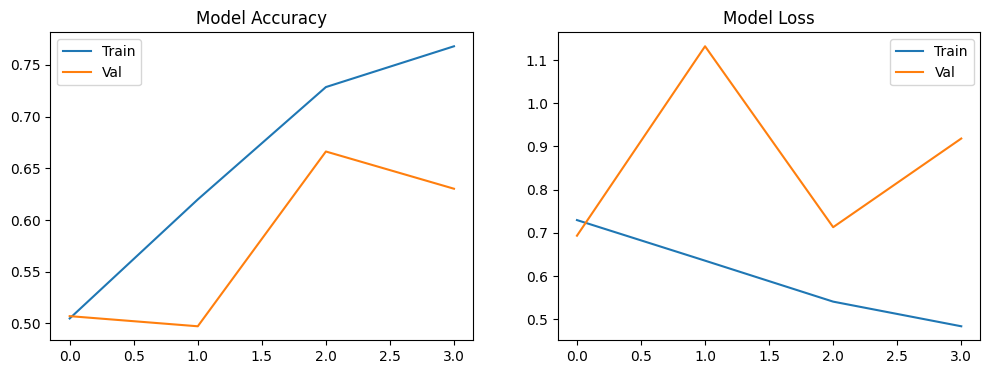

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


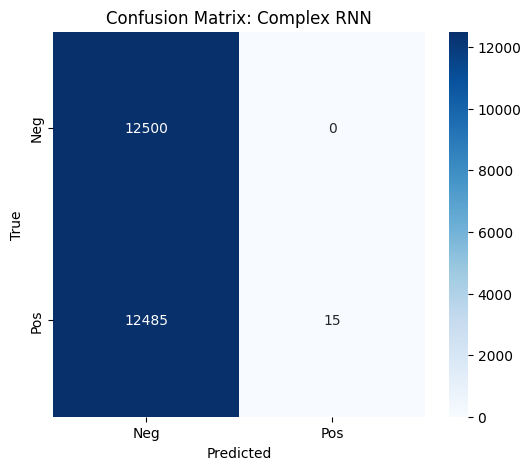

              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67     12500
    Positive       1.00      0.00      0.00     12500

    accuracy                           0.50     25000
   macro avg       0.75      0.50      0.33     25000
weighted avg       0.75      0.50      0.33     25000



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Plot Training History
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title('Model Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title('Model Loss')
    ax2.legend()
    plt.show()

plot_history(history)

# 2. Confusion Matrix Analysis
y_pred = (model.predict(x_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Confusion Matrix: Complex RNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 3. Detailed Metrics
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

#Building a deep, complex LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

def build_complex_lstm():
    model = Sequential([
        # 1. Input Layer
        Input(shape=(maxlen,)),

        # 2. Embedding Layer
        Embedding(input_dim=max_features, output_dim=128),

        # 3. First LSTM Layer
        # return_sequences=True is required to stack another LSTM
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),

        # 4. Second LSTM Layer
        LSTM(64, dropout=0.2),
        BatchNormalization(),

        # 5. Classifier
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize and verify parameter count
model_lstm = build_complex_lstm()
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,465,985 (5.59 MB)

 Trainable params: 1,465,601 (5.59 MB)

 Non-trainable params: 384 (1.50 KB)

#Training the LSTM

In [ ]:
# Re-using the same early stopping criteria for a fair comparison
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Complex Stacked LSTM...")
history_lstm = model_lstm.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Training Complex Stacked LSTM...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 217s 661ms/step - accuracy: 0.7070 - loss: 0.5747 - val_accuracy: 0.5698 - val_loss: 0.6670
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 206s 658ms/step - accuracy: 0.8530 - loss: 0.3468 - val_accuracy: 0.6772 - val_loss: 0.6461
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 262s 659ms/step - accuracy: 0.8869 - loss: 0.2787 - val_accuracy: 0.8052 - val_loss: 0.5393
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 663ms/step - accuracy: 0.9121 - loss: 0.2240 - val_accuracy: 0.8318 - val_loss: 0.4187
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 663ms/step - accuracy: 0.9360 - loss: 0.1693 - val_accuracy: 0.8578 - val_loss: 0.3933
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 661ms/step - accuracy: 0.9492 - loss: 0.1329 - val_accuracy: 0.8586 - val_loss: 0.4086
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 661ms/step - accuracy: 0.9593 - loss: 0.1084 - val_accuracy: 0.8352 - val_loss: 0.6116
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 206

#LSTM Performance Analysis & Comparison

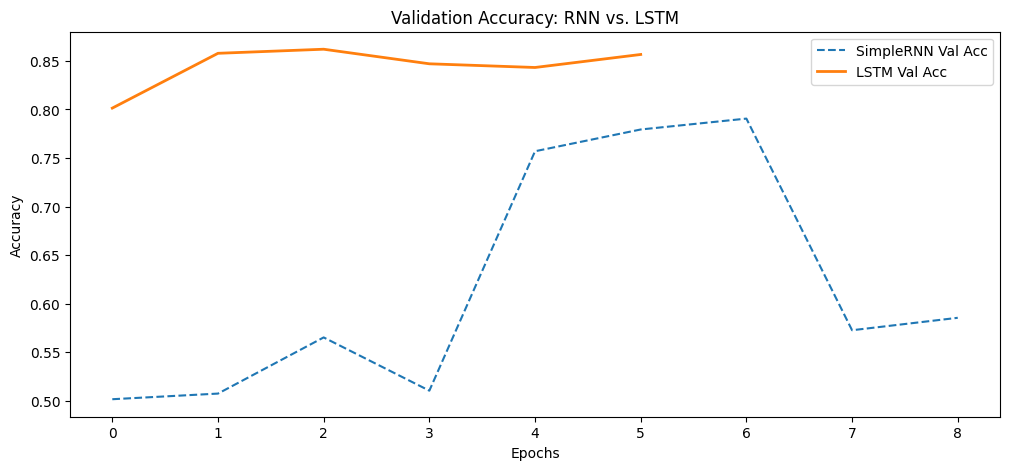

Final LSTM Test Accuracy: 0.8609
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
Sentiment Prediction (0=Neg, 1=Pos): 0.4853


In [ ]:
# 1. Compare Training Histories
plt.figure(figsize=(12, 5))
plt.plot(history.history['val_accuracy'], label='SimpleRNN Val Acc', linestyle='--')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Acc', linewidth=2)
plt.title('Validation Accuracy: RNN vs. LSTM')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 2. Final Evaluation
lstm_score, lstm_acc = model_lstm.evaluate(x_test, y_test, verbose=0)
print(f"Final LSTM Test Accuracy: {lstm_acc:.4f}")

# 3. Predict on a long sample to test 'Long-term Dependency'
sample_long_review = x_test[0:1]
prediction = model_lstm.predict(sample_long_review)
print(f"Sentiment Prediction (0=Neg, 1=Pos): {prediction[0][0]:.4f}")

#Building a Deep, Complex GRU

In [ ]:
from tensorflow.keras.layers import GRU

def build_complex_gru():
    model = Sequential([
        # 1. Input Layer
        Input(shape=(maxlen,)),

        # 2. Embedding Layer
        Embedding(input_dim=max_features, output_dim=128),

        # 3. First GRU Layer
        # return_sequences=True allows stacking
        GRU(128, return_sequences=True, dropout=0.2),
        BatchNormalization(),

        # 4. Second GRU Layer
        GRU(64, dropout=0.2),
        BatchNormalization(),

        # 5. Classifier
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize and verify
model_gru = build_complex_gru()
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 200, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,421,313 (5.42 MB)

 Trainable params: 1,420,929 (5.42 MB)

 Non-trainable params: 384 (1.50 KB)

#Training

In [ ]:
print("Training Complex Stacked GRU...")
history_gru = model_gru.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop] # Reusing the EarlyStopping from before
)

Training Complex Stacked GRU...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6902 - loss: 0.5780 - val_accuracy: 0.5782 - val_loss: 0.7022
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8839 - loss: 0.2875 - val_accuracy: 0.8116 - val_loss: 0.4498
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9258 - loss: 0.1981 - val_accuracy: 0.8320 - val_loss: 0.4205


#Final Comparison

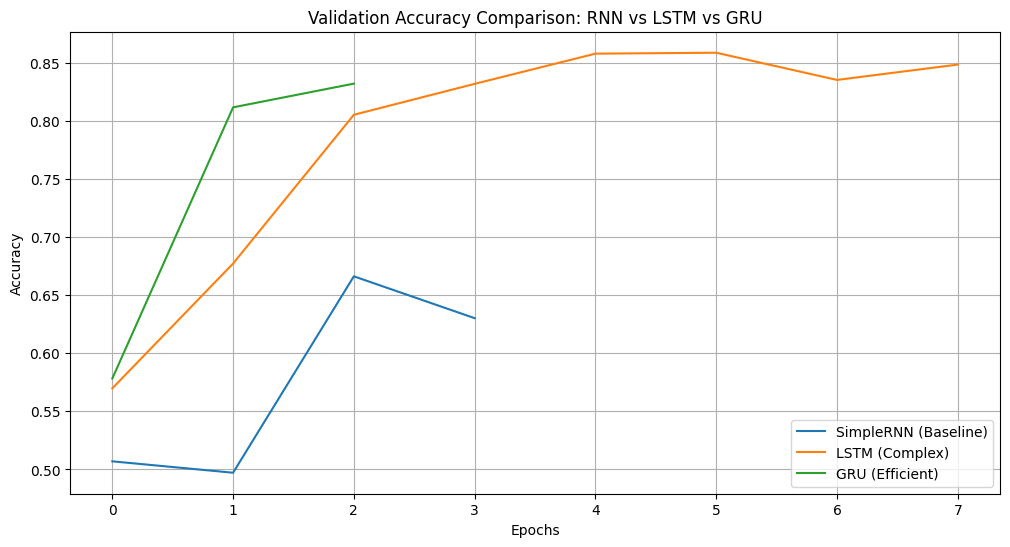

Model           | Test Accuracy  
-----------------------------------
SimpleRNN       | 0.5006
LSTM            | 0.8530
GRU             | 0.5837


In [ ]:
# 1. Compare Accuracy across all three models
plt.figure(figsize=(12, 6))
plt.plot(history.history['val_accuracy'], label='SimpleRNN (Baseline)')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM (Complex)')
plt.plot(history_gru.history['val_accuracy'], label='GRU (Efficient)')
plt.title('Validation Accuracy Comparison: RNN vs LSTM vs GRU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2. Final Test Results Table

# Evaluate the SimpleRNN model to get its test accuracy
rnn_score, acc = model.evaluate(x_test, y_test, verbose=0)

# Evaluate the LSTM model to get its test accuracy
lstm_score, lstm_acc = model_lstm.evaluate(x_test, y_test, verbose=0)

gru_score, gru_acc = model_gru.evaluate(x_test, y_test, verbose=0)

print(f"{'Model':<15} | {'Test Accuracy':<15}")
print("-" * 35)
print(f"{'SimpleRNN':<15} | {acc:.4f}") # acc from your first RNN run
print(f"{'LSTM':<15} | {lstm_acc:.4f}") # lstm_acc from previous run
print(f"{'GRU':<15} | {gru_acc:.4f}")